# Experiment 12: Full Dynasty Trajectory + Multilingual Poetic Geography

**Direction E (extended)**: Map the historical evolution of Chinese poetry (唐→宋→元→明→清) through activation space,
then test **14 languages** to determine whether poetic representations cluster by **language family** or
**geographic/cultural proximity**.

**Data**: larryvrh/Chinese-Poems (5 dynasties) + PoetryMTEB/MultilingualPoetryDatabase (14 languages)  
**Model**: Qwen3-8B Q4_K_M (36 layers, 4096 dim)  
**Builds on**: Exp 2 (aesthetic direction), Exp 4 (cross-lingual universality), Exp 7 (Tang vs Song)

### Languages & Contrasts

| Language | ISO | Family | Sub-family | Geography |
|---|---|---|---|---|
| Chinese | ZHO | Sino-Tibetan | Sinitic | East Asia |
| Japanese | JPN | Japonic | — | East Asia |
| Korean | KOR | Koreanic | — | East Asia |
| Arabic | ARA | Afro-Asiatic | Semitic | Middle East |
| Turkish | TUR | Turkic | Oghuz | Middle East |
| Persian | FAS | Indo-European | Iranian | Middle East |
| Hindi | HIN | Indo-European | Indo-Aryan | South Asia |
| Russian | RUS | Indo-European | Slavic | E. Europe |
| German | DEU | Indo-European | Germanic | W. Europe |
| English | ENG | Indo-European | Germanic | W. Europe |
| French | FRA | Indo-European | Romance | W. Europe |
| Spanish | SPA | Indo-European | Romance | W. Europe |
| Italian | ITA | Indo-European | Romance | S. Europe |
| Portuguese | POR | Indo-European | Romance | S. Europe |

**Key question**: In the model's poetic representation, does **language family** or **geographic/cultural proximity** better predict clustering?

In [1]:
import os, sys, json, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.spatial.distance import pdist, squareform, cosine
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from collections import Counter

os.environ['GGML_CUDA_DISABLE_GRAPHS'] = '1'
os.environ['HF_HOME'] = '/workspace/Data/huggingface_cache'
os.environ['TORCH_HOME'] = '/workspace/Data/torch_cache'
sys.path.insert(0, '/workspace/NeuroScope/build/python')
import neuroscope

# CJK fonts
for f in fm.findSystemFonts():
    if 'noto' in f.lower() and 'cjk' in f.lower():
        fm.fontManager.addfont(f)
plt.rcParams.update({
    'font.family': ['Noto Sans CJK SC', 'Noto Sans CJK JP', 'DejaVu Sans'],
    'axes.unicode_minus': False, 'figure.dpi': 150, 'figure.facecolor': 'white',
})

MODEL_PATH = '/workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf'
OUTPUT_DIR = Path('/workspace/Data/direction_E')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# Load Exp 2 results for aesthetic projection
exp2 = np.load('/workspace/Data/aesthetic_experiment/aesthetic_analysis_results.npz', allow_pickle=True)
aesthetic_dir_norm = exp2['aesthetic_direction_norm']   # (36, 4096)
best_layer = int(exp2['best_cls_layer'])               # 16
aesthetic_dir = exp2['aesthetic_direction']             # (4096,)
N_LAYERS = aesthetic_dir_norm.shape[0]

TARGET_LAYERS = [0, 4, 8, 12, 16, 20, 24, 28, 32, 35]

# Load engine
engine = neuroscope.Engine(MODEL_PATH, n_ctx=4096, n_gpu_layers=-1, verbose=False)
info = engine.model_info
print(f'Engine: {info.name} ({info.n_layers}L, {info.n_embd}D)')
print(f'Aesthetic direction loaded: best_layer=L{best_layer}')
print(f'Target layers: {TARGET_LAYERS}')

Engine: Qwen3 8B Awq Compatible Instruct (36L, 4096D)
Aesthetic direction loaded: best_layer=L16
Target layers: [0, 4, 8, 12, 16, 20, 24, 28, 32, 35]


ggml_cuda_init: found 1 CUDA devices:
  Device 0: NVIDIA GB10, compute capability 12.1, VMM: yes
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 108513128
ggml_backend_cuda_get_available_uma_memory: final available_memory_kb: 108513128
llama_model_load_from_file_impl: using device CUDA0 (NVIDIA GB10) (000f:01:00.0) - 105969 MiB free
llama_model_loader: loaded meta data with 28 key-value pairs and 399 tensors from /workspace/Model/Qwen3-8B-GGUF/Qwen3-8B-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = qwen3
llama_model_loader: - kv   1:                               general.type str              = model
llama_model_loader: - kv   2:                               general.name str              = Qwen3 8B Awq Compatible Instruct
llama_model_loader: - kv   3:                           genera

In [2]:
# ===== LANGUAGE METADATA =====
LANG_META = {
    'ZHO': {'family': 'Sino-Tibetan',   'subfamily': 'Sinitic',    'geo': 'East Asia',    'color': '#e41a1c'},
    'JPN': {'family': 'Japonic',         'subfamily': '-',          'geo': 'East Asia',    'color': '#ff7f00'},
    'KOR': {'family': 'Koreanic',        'subfamily': '-',          'geo': 'East Asia',    'color': '#a65628'},
    'ARA': {'family': 'Afro-Asiatic',    'subfamily': 'Semitic',    'geo': 'Middle East',  'color': '#984ea3'},
    'TUR': {'family': 'Turkic',          'subfamily': 'Oghuz',      'geo': 'Middle East',  'color': '#f781bf'},
    'FAS': {'family': 'Indo-European',   'subfamily': 'Iranian',    'geo': 'Middle East',  'color': '#999999'},
    'HIN': {'family': 'Indo-European',   'subfamily': 'Indo-Aryan', 'geo': 'South Asia',   'color': '#4daf4a'},
    'RUS': {'family': 'Indo-European',   'subfamily': 'Slavic',     'geo': 'E. Europe',    'color': '#377eb8'},
    'DEU': {'family': 'Indo-European',   'subfamily': 'Germanic',   'geo': 'W. Europe',    'color': '#66c2a5'},
    'ENG': {'family': 'Indo-European',   'subfamily': 'Germanic',   'geo': 'W. Europe',    'color': '#fc8d62'},
    'FRA': {'family': 'Indo-European',   'subfamily': 'Romance',    'geo': 'W. Europe',    'color': '#8da0cb'},
    'SPA': {'family': 'Indo-European',   'subfamily': 'Romance',    'geo': 'W. Europe',    'color': '#e78ac3'},
    'ITA': {'family': 'Indo-European',   'subfamily': 'Romance',    'geo': 'S. Europe',    'color': '#a6d854'},
    'POR': {'family': 'Indo-European',   'subfamily': 'Romance',    'geo': 'S. Europe',    'color': '#ffd92f'},
}

# ===== LOAD MULTILINGUAL POETRY (PoetryMTEB) =====
from datasets import load_dataset
print('Loading PoetryMTEB/MultilingualPoetryDatabase ...')
t0 = time.time()
mteb_ds = load_dataset('PoetryMTEB/MultilingualPoetryDatabase', 'corpus', split='test')
print(f'  Loaded {len(mteb_ds)} poems in {time.time()-t0:.1f}s')

# Group by language, filter for reasonable length
N_PER_LANG = 30
mteb_poems = {}  # lang -> list of content strings

for lang_code in LANG_META:
    if lang_code == 'ZHO':
        continue  # We'll use larryvrh for Chinese
    candidates = []
    for item in mteb_ds:
        if item['language'] == lang_code:
            c = item['content'].strip()
            # Filter: reasonable length
            if lang_code in ('JPN', 'KOR'):
                if 10 <= len(c) <= 300:
                    candidates.append(c)
            else:
                if 20 <= len(c) <= 500:
                    candidates.append(c)
        if len(candidates) >= 200:  # enough candidates collected
            break
    np.random.shuffle(candidates)
    mteb_poems[lang_code] = candidates[:N_PER_LANG]
    print(f'  {lang_code}: {len(mteb_poems[lang_code])} poems (from {len(candidates)} candidates)')

# ===== LOAD CHINESE POEMS BY DYNASTY (larryvrh) =====
with open('/workspace/Data/poetry_data/chinese_poems.json') as f:
    zh_data = json.load(f)

DYNASTY_ORDER = ['唐代', '宋代', '元代', '明代', '清代']
DYNASTY_SHORT = {'唐代': 'Tang', '宋代': 'Song', '元代': 'Yuan', '明代': 'Ming', '清代': 'Qing'}
dynasty_poems = {}  # dynasty -> list of content strings
for d in DYNASTY_ORDER:
    candidates = [p['content'] for p in zh_data if p['dynasty'] == d and 10 <= len(p['content']) <= 200]
    np.random.shuffle(candidates)
    dynasty_poems[d] = candidates[:N_PER_LANG]
    print(f'  ZHO-{DYNASTY_SHORT[d]}: {len(dynasty_poems[d])} poems')

# Combine all ZHO poems (sample 30 from all dynasties for multilingual comparison)
all_zh = []
for d in DYNASTY_ORDER:
    all_zh.extend(dynasty_poems[d])
np.random.shuffle(all_zh)
mteb_poems['ZHO'] = all_zh[:N_PER_LANG]  # 30 for multilingual analysis

# Clean up large dataset from memory
del mteb_ds
import gc; gc.collect()

total = sum(len(v) for v in mteb_poems.values()) + sum(len(v) for v in dynasty_poems.values()) - len(mteb_poems['ZHO'])
print(f'\nTotal unique texts: {total}')
print(f'Multilingual: {sum(len(v) for v in mteb_poems.values())} (14 langs × ~{N_PER_LANG})')
print(f'Dynasty: {sum(len(v) for v in dynasty_poems.values())} (5 dynasties × ~{N_PER_LANG})')

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading PoetryMTEB/MultilingualPoetryDatabase ...
  Loaded 823972 poems in 0.9s
  JPN: 30 poems (from 200 candidates)
  KOR: 15 poems (from 15 candidates)
  ARA: 30 poems (from 200 candidates)
  TUR: 30 poems (from 200 candidates)
  FAS: 30 poems (from 200 candidates)
  HIN: 30 poems (from 200 candidates)
  RUS: 30 poems (from 200 candidates)
  DEU: 30 poems (from 200 candidates)
  ENG: 30 poems (from 200 candidates)
  FRA: 30 poems (from 200 candidates)
  SPA: 30 poems (from 200 candidates)
  ITA: 30 poems (from 200 candidates)
  POR: 30 poems (from 200 candidates)
  ZHO-Tang: 30 poems
  ZHO-Song: 30 poems
  ZHO-Yuan: 30 poems
  ZHO-Ming: 30 poems
  ZHO-Qing: 30 poems

Total unique texts: 525
Multilingual: 405 (14 langs × ~30)
Dynasty: 150 (5 dynasties × ~30)


In [3]:
# ===== EXTRACT ACTIVATIONS =====
# For each text, forward and collect activations at TARGET_LAYERS

def extract_acts(texts, label=''):
    """Forward each text and return activations dict: {layer: np.array (N, n_embd)}."""
    acts = {l: [] for l in TARGET_LAYERS}
    for i, text in enumerate(texts):
        engine.reset()
        ok = engine.forward(text, add_special=True)
        if not ok:
            print(f'  WARN: forward failed for {label}[{i}]')
            continue
        for l in TARGET_LAYERS:
            acts[l].append(engine.get_activations(l).copy())
    for l in TARGET_LAYERS:
        acts[l] = np.array(acts[l])
    return acts

# --- Multilingual activations ---
print('Extracting multilingual activations ...')
t0 = time.time()
multi_acts = {}  # lang -> {layer: (N, 4096)}
for lang_code in sorted(LANG_META.keys()):
    multi_acts[lang_code] = extract_acts(mteb_poems[lang_code], label=lang_code)
    n = multi_acts[lang_code][TARGET_LAYERS[0]].shape[0]
    print(f'  {lang_code}: {n} poems')
dt1 = time.time() - t0
print(f'  Done in {dt1:.1f}s')

# --- Dynasty activations (full set for trajectory) ---
print('\nExtracting dynasty activations ...')
t0 = time.time()
dynasty_acts = {}  # dynasty_label -> {layer: (N, 4096)}
for d in DYNASTY_ORDER:
    label = DYNASTY_SHORT[d]
    dynasty_acts[label] = extract_acts(dynasty_poems[d], label=label)
    n = dynasty_acts[label][TARGET_LAYERS[0]].shape[0]
    print(f'  {label}: {n} poems')
dt2 = time.time() - t0
print(f'  Done in {dt2:.1f}s')
print(f'\nTotal extraction time: {dt1+dt2:.1f}s')

Extracting multilingual activations ...
  ARA: 30 poems
  DEU: 30 poems
  ENG: 30 poems
  FAS: 30 poems
  FRA: 30 poems
  WARN: forward failed for HIN[3]


find_slot: n_tokens = 278 > size = 256
decode: failed to find a memory slot for batch of size 278
[CoreEngine] Error: Prefill failed
find_slot: n_tokens = 286 > size = 256
decode: failed to find a memory slot for batch of size 286
[CoreEngine] Error: Prefill failed
find_slot: n_tokens = 307 > size = 256
decode: failed to find a memory slot for batch of size 307
[CoreEngine] Error: Prefill failed


  WARN: forward failed for HIN[10]
  WARN: forward failed for HIN[11]
  WARN: forward failed for HIN[27]
  HIN: 26 poems


find_slot: n_tokens = 286 > size = 256
decode: failed to find a memory slot for batch of size 286
[CoreEngine] Error: Prefill failed


  ITA: 30 poems
  JPN: 30 poems
  KOR: 15 poems
  POR: 30 poems
  RUS: 30 poems
  SPA: 30 poems
  TUR: 30 poems
  ZHO: 30 poems
  Done in 28.9s

Extracting dynasty activations ...
  Tang: 30 poems
  Song: 30 poems
  Yuan: 30 poems
  Ming: 30 poems
  Qing: 30 poems
  Done in 10.5s

Total extraction time: 39.4s


## Part A: Chinese Dynasty Trajectory (唐→宋→元→明→清)

Map the 5-dynasty evolution through activation space. Does the historical evolution of Chinese
poetry style trace a continuous path or show discrete clusters?

findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

Dynasty matrix: (150, 4096)
PCA explained variance: PC1=0.239, PC2=0.058
  Tang: aesthetic proj = 5.47 ± 0.95
  Song: aesthetic proj = 5.66 ± 1.09
  Yuan: aesthetic proj = 4.74 ± 1.62
  Ming: aesthetic proj = 5.66 ± 1.15
  Qing: aesthetic proj = 4.77 ± 1.26

Dynasty centroid distances (L16, cosine):
  Tang-Song: 0.0145
  Tang-Yuan: 0.0458
  Tang-Ming: 0.0118
  Tang-Qing: 0.0655
  Song-Yuan: 0.0450
  Song-Ming: 0.0148
  Song-Qing: 0.0651
  Yuan-Ming: 0.0341
  Yuan-Qing: 0.0136
  Ming-Qing: 0.0505


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

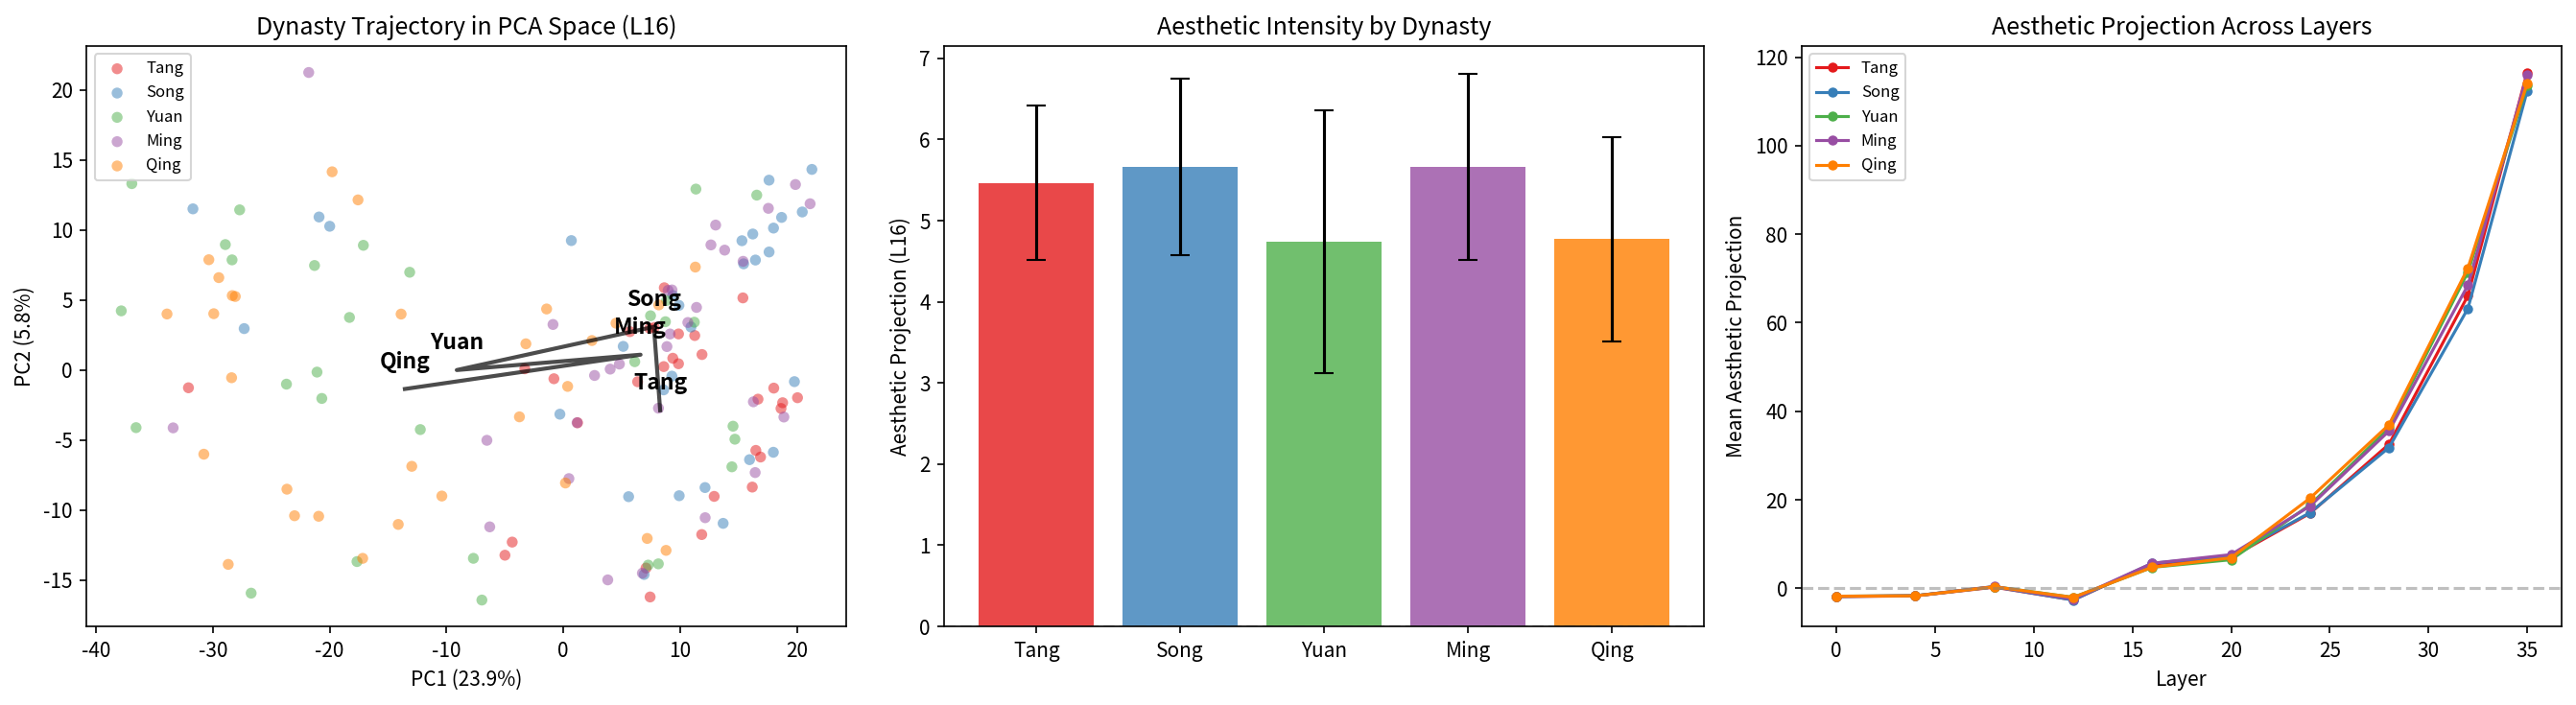

Saved dynasty_trajectory.png


In [4]:
# ===== DYNASTY TRAJECTORY AT L16 =====
L = 16
dynasty_labels = list(DYNASTY_SHORT.values())  # Tang, Song, Yuan, Ming, Qing
dynasty_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00']

# Collect all dynasty activations at L16
all_dynasty_vecs = []
all_dynasty_tags = []
for d_label in dynasty_labels:
    vecs = dynasty_acts[d_label][L]
    all_dynasty_vecs.append(vecs)
    all_dynasty_tags.extend([d_label] * len(vecs))
all_dynasty_mat = np.vstack(all_dynasty_vecs)
print(f'Dynasty matrix: {all_dynasty_mat.shape}')

# PCA on dynasty data
pca = PCA(n_components=2)
dynasty_pca = pca.fit_transform(all_dynasty_mat)
print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')

# Compute centroids
centroids = {}
for i, d_label in enumerate(dynasty_labels):
    mask = [t == d_label for t in all_dynasty_tags]
    centroids[d_label] = dynasty_pca[mask].mean(axis=0)

# Aesthetic projection per dynasty
aes_proj = {}
for d_label in dynasty_labels:
    vecs = dynasty_acts[d_label][L]
    proj = vecs @ aesthetic_dir_norm[L]
    aes_proj[d_label] = (proj.mean(), proj.std())
    print(f'  {d_label}: aesthetic proj = {proj.mean():.2f} ± {proj.std():.2f}')

# Pairwise distances between dynasty centroids (in original space)
print('\nDynasty centroid distances (L16, cosine):')
for i, d1 in enumerate(dynasty_labels):
    c1 = dynasty_acts[d1][L].mean(axis=0)
    for j, d2 in enumerate(dynasty_labels):
        if j > i:
            c2 = dynasty_acts[d2][L].mean(axis=0)
            d = cosine(c1, c2)
            print(f'  {d1}-{d2}: {d:.4f}')

# === PLOT ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PCA scatter with trajectory
ax = axes[0]
for i, d_label in enumerate(dynasty_labels):
    mask = np.array([t == d_label for t in all_dynasty_tags])
    ax.scatter(dynasty_pca[mask, 0], dynasty_pca[mask, 1],
               c=dynasty_colors[i], alpha=0.5, s=30, label=d_label, edgecolors='none')
# Draw trajectory through centroids
cx = [centroids[d][0] for d in dynasty_labels]
cy = [centroids[d][1] for d in dynasty_labels]
ax.plot(cx, cy, 'k-', linewidth=2, alpha=0.7, zorder=5)
for i, d_label in enumerate(dynasty_labels):
    ax.annotate(d_label, centroids[d_label], fontsize=11, fontweight='bold',
                ha='center', va='bottom', xytext=(0, 8), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Dynasty Trajectory in PCA Space (L16)')
ax.legend(fontsize=8, loc='best')

# 2. Aesthetic projection by dynasty
ax = axes[1]
means = [aes_proj[d][0] for d in dynasty_labels]
stds = [aes_proj[d][1] for d in dynasty_labels]
bars = ax.bar(dynasty_labels, means, yerr=stds, color=dynasty_colors, alpha=0.8, capsize=5)
ax.set_ylabel('Aesthetic Projection (L16)')
ax.set_title('Aesthetic Intensity by Dynasty')
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 3. Multi-layer aesthetic projection
ax = axes[2]
for i, d_label in enumerate(dynasty_labels):
    layer_projs = []
    for l in TARGET_LAYERS:
        vecs = dynasty_acts[d_label][l]
        proj = vecs @ aesthetic_dir_norm[l]
        layer_projs.append(proj.mean())
    ax.plot(TARGET_LAYERS, layer_projs, 'o-', color=dynasty_colors[i], label=d_label, markersize=4)
ax.set_xlabel('Layer')
ax.set_ylabel('Mean Aesthetic Projection')
ax.set_title('Aesthetic Projection Across Layers')
ax.legend(fontsize=8)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dynasty_trajectory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved dynasty_trajectory.png')

## Part B: Multilingual Poetry Map — Language Family vs Geography

Project 14 languages into shared activation space. Color by language family and geography
to test which predicts clustering better.

Multilingual matrix: (401, 4096) (14 languages)
Running t-SNE ...


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

  t-SNE done, KL divergence: 0.8575
  PCA: PC1=0.093, PC2=0.042


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

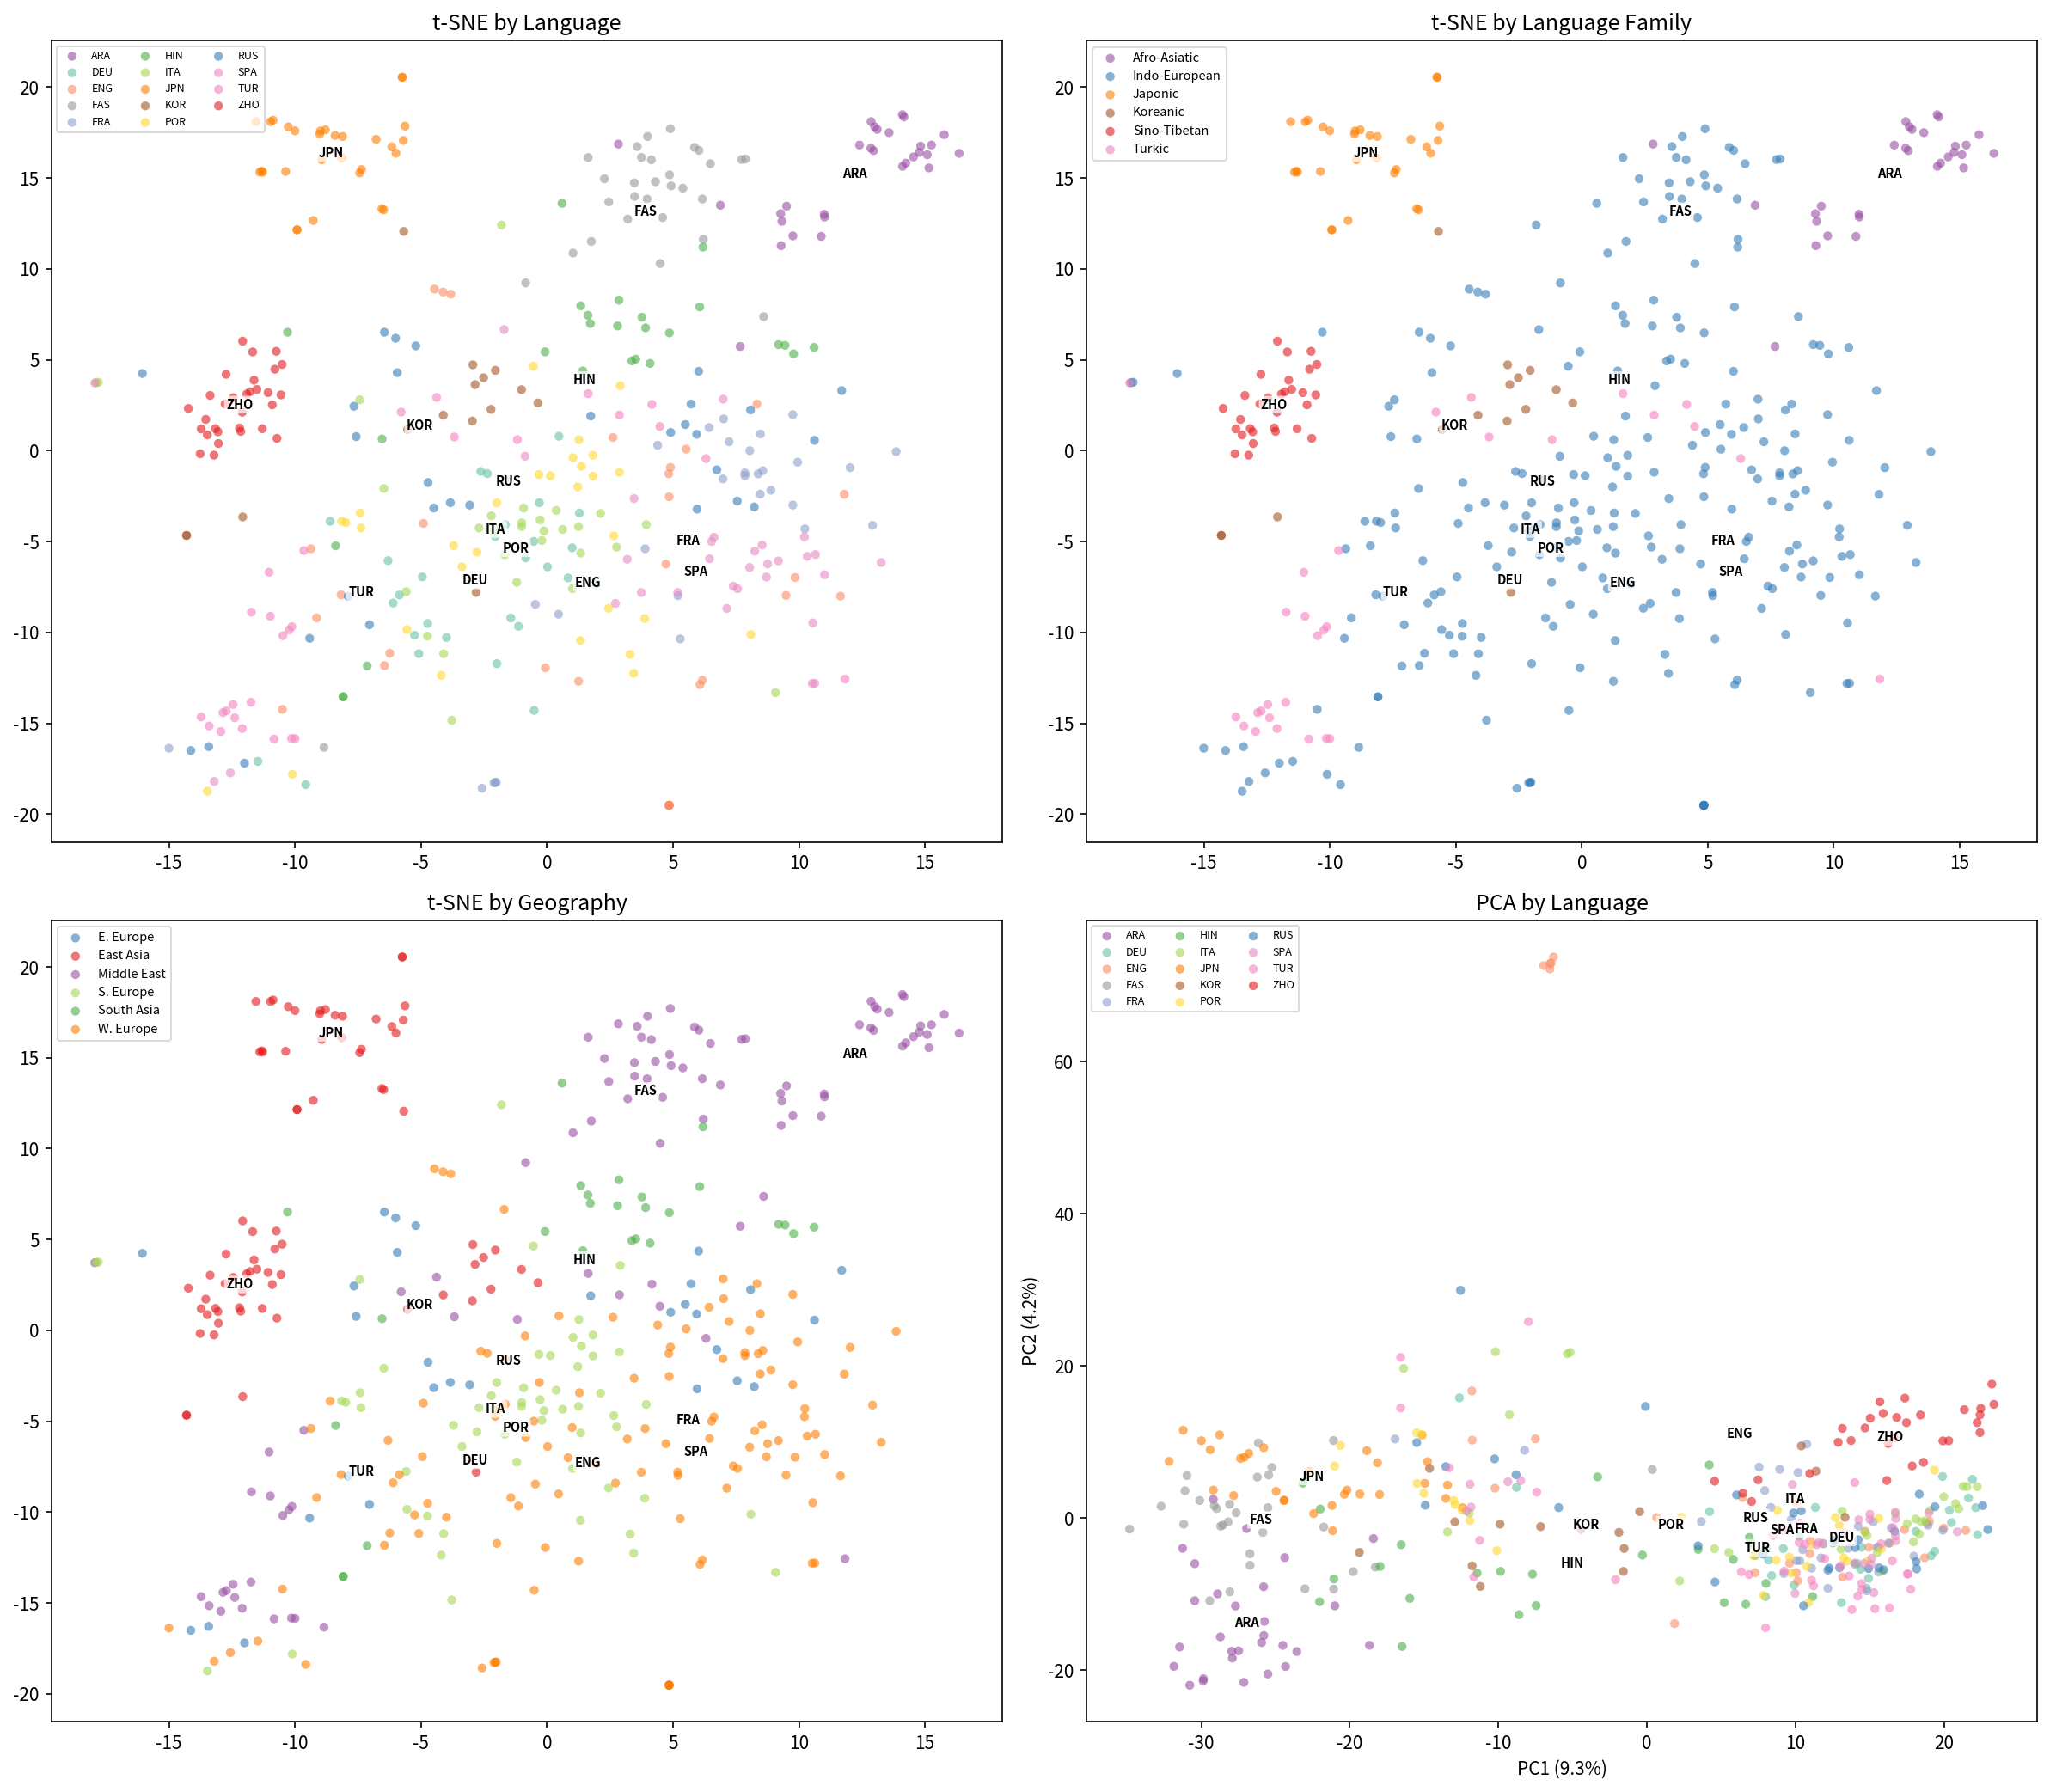

Saved multilingual_map.png


In [6]:
# ===== MULTILINGUAL MAP AT L16 =====
L = 16

# Collect all multilingual activations
all_multi_vecs = []
all_multi_langs = []
all_multi_families = []
all_multi_geos = []

for lang_code in sorted(LANG_META.keys()):
    vecs = multi_acts[lang_code][L]
    all_multi_vecs.append(vecs)
    all_multi_langs.extend([lang_code] * len(vecs))
    all_multi_families.extend([LANG_META[lang_code]['family']] * len(vecs))
    all_multi_geos.extend([LANG_META[lang_code]['geo']] * len(vecs))

all_multi_mat = np.vstack(all_multi_vecs)
print(f'Multilingual matrix: {all_multi_mat.shape} ({len(set(all_multi_langs))} languages)')

# t-SNE
print('Running t-SNE ...')
tsne = TSNE(n_components=2, perplexity=min(30, len(all_multi_mat)//4), random_state=SEED, max_iter=1000)
tsne_coords = tsne.fit_transform(all_multi_mat)
print(f'  t-SNE done, KL divergence: {tsne.kl_divergence_:.4f}')

# PCA for comparison
pca_multi = PCA(n_components=2)
pca_coords = pca_multi.fit_transform(all_multi_mat)
print(f'  PCA: PC1={pca_multi.explained_variance_ratio_[0]:.3f}, PC2={pca_multi.explained_variance_ratio_[1]:.3f}')

# Compute centroids in t-SNE space
tsne_centroids = {}
for lang_code in sorted(LANG_META.keys()):
    mask = np.array([l == lang_code for l in all_multi_langs])
    tsne_centroids[lang_code] = tsne_coords[mask].mean(axis=0)

# === PLOT: 2x2 grid ===
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Define family and geo color maps
FAMILY_COLORS = {
    'Sino-Tibetan': '#e41a1c', 'Japonic': '#ff7f00', 'Koreanic': '#a65628',
    'Afro-Asiatic': '#984ea3', 'Turkic': '#f781bf',
    'Indo-European': '#377eb8', 'Uralic': '#4daf4a',
}
GEO_COLORS = {
    'East Asia': '#e41a1c', 'Middle East': '#984ea3',
    'South Asia': '#4daf4a', 'E. Europe': '#377eb8',
    'W. Europe': '#ff7f00', 'S. Europe': '#a6d854',
}

# 1. t-SNE colored by LANGUAGE (individual colors)
ax = axes[0, 0]
for lang_code in sorted(LANG_META.keys()):
    mask = np.array([l == lang_code for l in all_multi_langs])
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               c=LANG_META[lang_code]['color'], alpha=0.6, s=25, label=lang_code, edgecolors='none')
    cx, cy = tsne_centroids[lang_code]
    ax.annotate(lang_code, (cx, cy), fontsize=7, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7, edgecolor='none'))
ax.set_title('t-SNE by Language')
ax.legend(fontsize=6, ncol=3, loc='upper left', framealpha=0.7)

# 2. t-SNE colored by FAMILY
ax = axes[0, 1]
for family in sorted(set(all_multi_families)):
    mask = np.array([f == family for f in all_multi_families])
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               c=FAMILY_COLORS.get(family, '#999999'), alpha=0.6, s=25, label=family, edgecolors='none')
for lang_code in sorted(LANG_META.keys()):
    cx, cy = tsne_centroids[lang_code]
    ax.annotate(lang_code, (cx, cy), fontsize=7, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7, edgecolor='none'))
ax.set_title('t-SNE by Language Family')
ax.legend(fontsize=7, loc='upper left', framealpha=0.7)

# 3. t-SNE colored by GEOGRAPHY
ax = axes[1, 0]
for geo in sorted(set(all_multi_geos)):
    mask = np.array([g == geo for g in all_multi_geos])
    ax.scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
               c=GEO_COLORS.get(geo, '#999999'), alpha=0.6, s=25, label=geo, edgecolors='none')
for lang_code in sorted(LANG_META.keys()):
    cx, cy = tsne_centroids[lang_code]
    ax.annotate(lang_code, (cx, cy), fontsize=7, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7, edgecolor='none'))
ax.set_title('t-SNE by Geography')
ax.legend(fontsize=7, loc='upper left', framealpha=0.7)

# 4. PCA colored by language (for comparison)
pca_centroids = {}
for lang_code in sorted(LANG_META.keys()):
    mask = np.array([l == lang_code for l in all_multi_langs])
    pca_centroids[lang_code] = pca_coords[mask].mean(axis=0)
ax = axes[1, 1]
for lang_code in sorted(LANG_META.keys()):
    mask = np.array([l == lang_code for l in all_multi_langs])
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
               c=LANG_META[lang_code]['color'], alpha=0.6, s=25, label=lang_code, edgecolors='none')
    cx, cy = pca_centroids[lang_code]
    ax.annotate(lang_code, (cx, cy), fontsize=7, fontweight='bold', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7, edgecolor='none'))
ax.set_xlabel(f'PC1 ({pca_multi.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_multi.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA by Language')
ax.legend(fontsize=6, ncol=3, loc='upper left', framealpha=0.7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'multilingual_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved multilingual_map.png')

=== Family Effect ===
  Within-family mean distance:  0.1241 ± 0.0671 (N=36)
  Between-family mean distance: 0.2147 ± 0.0828 (N=55)
  Mann-Whitney U p = 0.000000

=== Geography Effect ===
  Within-geo mean distance:  0.1576 ± 0.0904 (N=13)
  Between-geo mean distance: 0.1824 ± 0.0881 (N=78)
  Mann-Whitney U p = 0.136874

=== Sub-family Effect (Romance, Germanic, Slavic, etc.) ===
  Within-subfamily mean distance:  0.0791 ± 0.0160 (N=7)
  Between-subfamily mean distance: 0.1871 ± 0.0874
  Mann-Whitney U p = 0.000054

=== Effect Sizes ===
  Family effect (Cohen's d): 1.020
  Geography effect (Cohen's d): 0.279
  Sub-family effect (Cohen's d): 1.216

=== Mantel Test (Permutation, N=5000) ===
  Family: r=0.4986, p=0.0158
  Geography: r=0.0977, p=0.1494
  → Family has stronger correlation with distance


findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

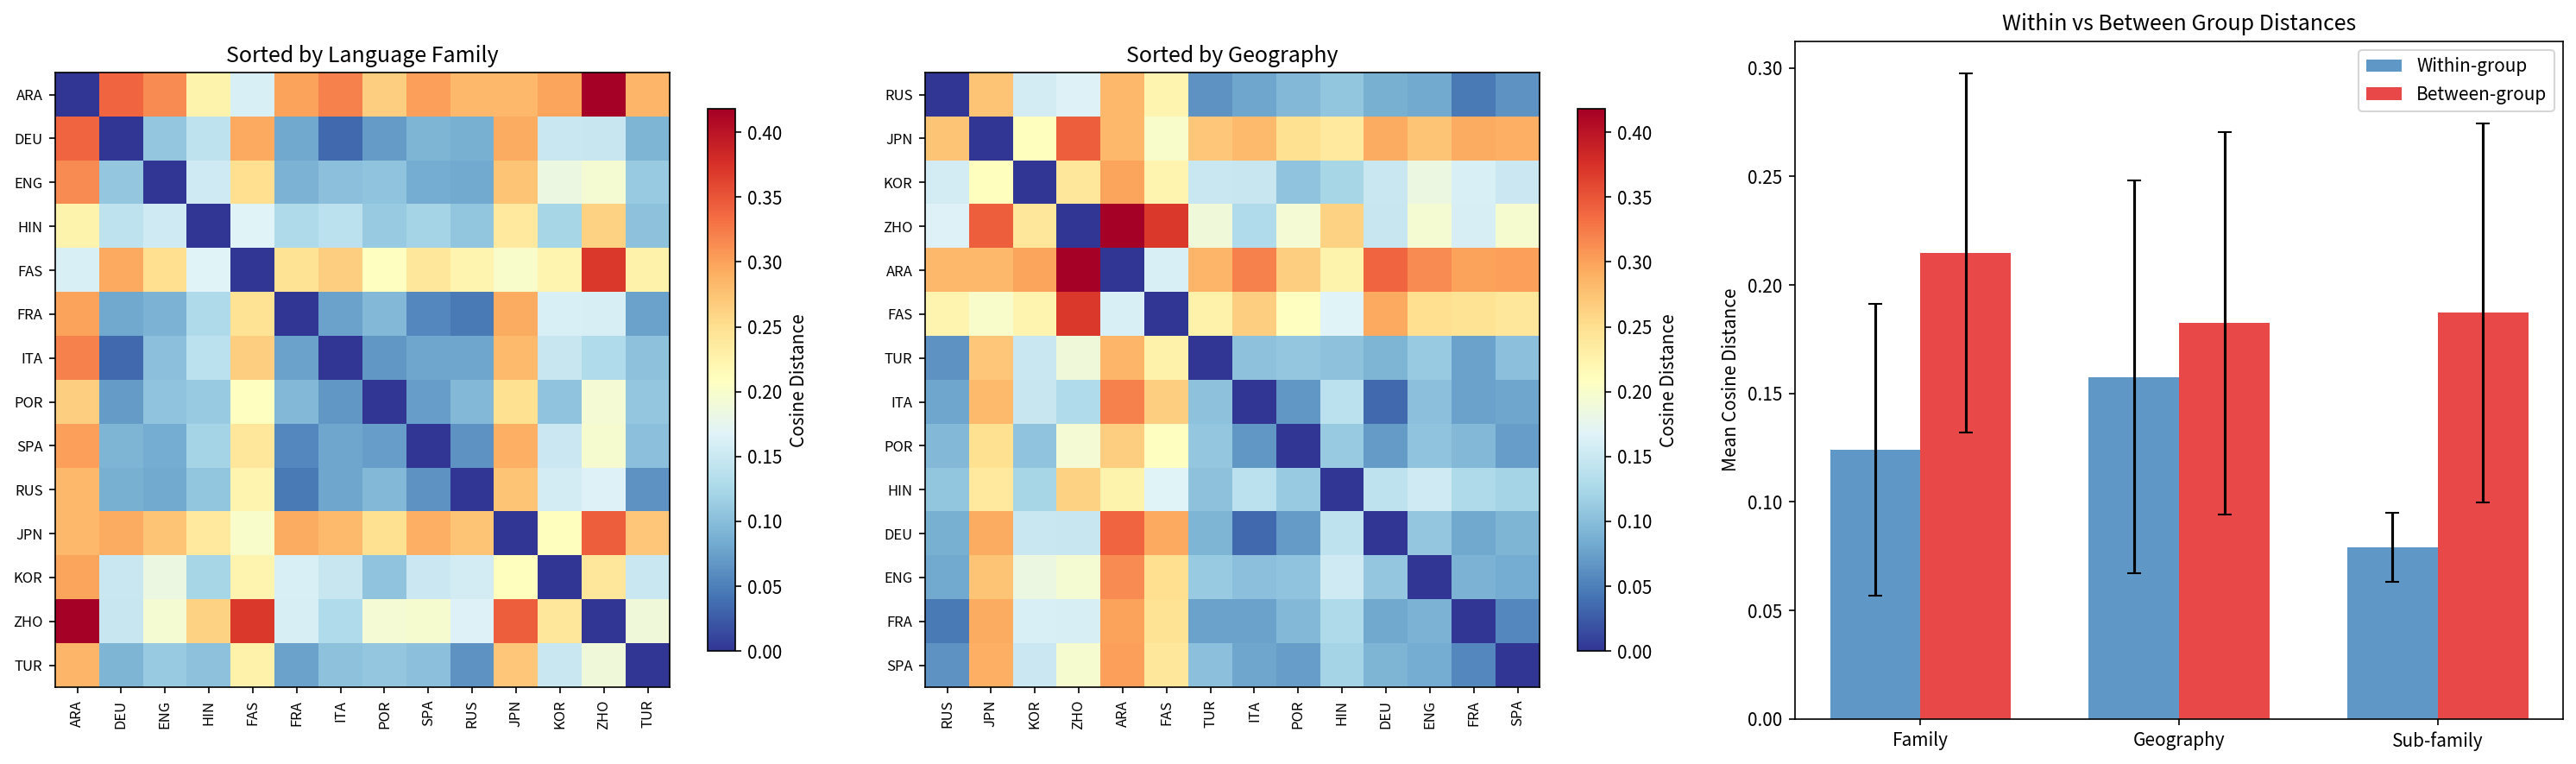

Saved distance_analysis.png


In [7]:
# ===== PAIRWISE CENTROID DISTANCES =====
L = 16
lang_list = sorted(LANG_META.keys())
n_langs = len(lang_list)

# Compute centroid in original space
centroids_orig = {}
for lc in lang_list:
    centroids_orig[lc] = multi_acts[lc][L].mean(axis=0)

# Cosine distance matrix
dist_matrix = np.zeros((n_langs, n_langs))
for i, l1 in enumerate(lang_list):
    for j, l2 in enumerate(lang_list):
        if i != j:
            dist_matrix[i, j] = cosine(centroids_orig[l1], centroids_orig[l2])

# Create binary indicator matrices
same_family = np.zeros((n_langs, n_langs))
same_geo = np.zeros((n_langs, n_langs))
same_subfamily = np.zeros((n_langs, n_langs))
for i, l1 in enumerate(lang_list):
    for j, l2 in enumerate(lang_list):
        if i != j:
            if LANG_META[l1]['family'] == LANG_META[l2]['family']:
                same_family[i, j] = 1
            if LANG_META[l1]['geo'] == LANG_META[l2]['geo']:
                same_geo[i, j] = 1
            if (LANG_META[l1]['subfamily'] == LANG_META[l2]['subfamily']
                and LANG_META[l1]['subfamily'] != '-'):
                same_subfamily[i, j] = 1

# Compute mean within vs between distances
upper = np.triu_indices(n_langs, k=1)
dists = dist_matrix[upper]
fam_mask = same_family[upper].astype(bool)
geo_mask = same_geo[upper].astype(bool)
subfam_mask = same_subfamily[upper].astype(bool)

print('=== Family Effect ===')
print(f'  Within-family mean distance:  {dists[fam_mask].mean():.4f} ± {dists[fam_mask].std():.4f} (N={fam_mask.sum()})')
print(f'  Between-family mean distance: {dists[~fam_mask].mean():.4f} ± {dists[~fam_mask].std():.4f} (N={(~fam_mask).sum()})')
t_fam, p_fam = stats.mannwhitneyu(dists[fam_mask], dists[~fam_mask], alternative='less')
print(f'  Mann-Whitney U p = {p_fam:.6f}')

print('\n=== Geography Effect ===')
print(f'  Within-geo mean distance:  {dists[geo_mask].mean():.4f} ± {dists[geo_mask].std():.4f} (N={geo_mask.sum()})')
print(f'  Between-geo mean distance: {dists[~geo_mask].mean():.4f} ± {dists[~geo_mask].std():.4f} (N={(~geo_mask).sum()})')
t_geo, p_geo = stats.mannwhitneyu(dists[geo_mask], dists[~geo_mask], alternative='less')
print(f'  Mann-Whitney U p = {p_geo:.6f}')

print('\n=== Sub-family Effect (Romance, Germanic, Slavic, etc.) ===')
if subfam_mask.sum() > 0:
    print(f'  Within-subfamily mean distance:  {dists[subfam_mask].mean():.4f} ± {dists[subfam_mask].std():.4f} (N={subfam_mask.sum()})')
    print(f'  Between-subfamily mean distance: {dists[~subfam_mask].mean():.4f} ± {dists[~subfam_mask].std():.4f}')
    t_sub, p_sub = stats.mannwhitneyu(dists[subfam_mask], dists[~subfam_mask], alternative='less')
    print(f'  Mann-Whitney U p = {p_sub:.6f}')

# Effect sizes (Cohen's d)
d_fam = (dists[~fam_mask].mean() - dists[fam_mask].mean()) / dists.std()
d_geo = (dists[~geo_mask].mean() - dists[geo_mask].mean()) / dists.std()
print(f'\n=== Effect Sizes ===')
print(f'  Family effect (Cohen\'s d): {d_fam:.3f}')
print(f'  Geography effect (Cohen\'s d): {d_geo:.3f}')
if subfam_mask.sum() > 0:
    d_sub = (dists[~subfam_mask].mean() - dists[subfam_mask].mean()) / dists.std()
    print(f'  Sub-family effect (Cohen\'s d): {d_sub:.3f}')

# === Permutation Test (Mantel-like) ===
N_PERM = 5000
def mantel_corr(dist_vec, indicator_vec):
    return np.corrcoef(dist_vec, indicator_vec)[0, 1]

obs_r_fam = mantel_corr(dists, 1 - fam_mask)  # higher dist = different family
obs_r_geo = mantel_corr(dists, 1 - geo_mask)
perm_r_fam = []
perm_r_geo = []

idx = np.arange(n_langs)
for _ in range(N_PERM):
    perm_idx = np.random.permutation(idx)
    # Permute rows+cols of indicator matrices
    perm_fam = same_family[np.ix_(perm_idx, perm_idx)]
    perm_geo = same_geo[np.ix_(perm_idx, perm_idx)]
    perm_r_fam.append(mantel_corr(dists, 1 - perm_fam[upper]))
    perm_r_geo.append(mantel_corr(dists, 1 - perm_geo[upper]))

p_mantel_fam = np.mean(np.array(perm_r_fam) >= obs_r_fam)
p_mantel_geo = np.mean(np.array(perm_r_geo) >= obs_r_geo)

print(f'\n=== Mantel Test (Permutation, N={N_PERM}) ===')
print(f'  Family: r={obs_r_fam:.4f}, p={p_mantel_fam:.4f}')
print(f'  Geography: r={obs_r_geo:.4f}, p={p_mantel_geo:.4f}')
print(f'  → {"Family" if obs_r_fam > obs_r_geo else "Geography"} has stronger correlation with distance')

# === PLOT: Distance heatmap ===
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Heatmap sorted by sub-family
sort_order_fam = sorted(range(n_langs), key=lambda i: (
    LANG_META[lang_list[i]]['family'],
    LANG_META[lang_list[i]]['subfamily'],
    lang_list[i]))
sorted_labels_fam = [lang_list[i] for i in sort_order_fam]
sorted_dist_fam = dist_matrix[np.ix_(sort_order_fam, sort_order_fam)]

ax = axes[0]
im = ax.imshow(sorted_dist_fam, cmap='RdYlBu_r', aspect='equal')
ax.set_xticks(range(n_langs)); ax.set_xticklabels(sorted_labels_fam, rotation=90, fontsize=8)
ax.set_yticks(range(n_langs)); ax.set_yticklabels(sorted_labels_fam, fontsize=8)
ax.set_title('Sorted by Language Family')
plt.colorbar(im, ax=ax, shrink=0.8, label='Cosine Distance')

# 2. Heatmap sorted by geography
sort_order_geo = sorted(range(n_langs), key=lambda i: (
    LANG_META[lang_list[i]]['geo'], lang_list[i]))
sorted_labels_geo = [lang_list[i] for i in sort_order_geo]
sorted_dist_geo = dist_matrix[np.ix_(sort_order_geo, sort_order_geo)]

ax = axes[1]
im = ax.imshow(sorted_dist_geo, cmap='RdYlBu_r', aspect='equal')
ax.set_xticks(range(n_langs)); ax.set_xticklabels(sorted_labels_geo, rotation=90, fontsize=8)
ax.set_yticks(range(n_langs)); ax.set_yticklabels(sorted_labels_geo, fontsize=8)
ax.set_title('Sorted by Geography')
plt.colorbar(im, ax=ax, shrink=0.8, label='Cosine Distance')

# 3. Bar chart: within vs between for family and geo
ax = axes[2]
x = np.arange(3)
within = [dists[fam_mask].mean(), dists[geo_mask].mean(),
          dists[subfam_mask].mean() if subfam_mask.sum() > 0 else 0]
between = [dists[~fam_mask].mean(), dists[~geo_mask].mean(),
           dists[~subfam_mask].mean() if subfam_mask.sum() > 0 else 0]
w_err = [dists[fam_mask].std(), dists[geo_mask].std(),
         dists[subfam_mask].std() if subfam_mask.sum() > 0 else 0]
b_err = [dists[~fam_mask].std(), dists[~geo_mask].std(),
         dists[~subfam_mask].std() if subfam_mask.sum() > 0 else 0]
width = 0.35
ax.bar(x - width/2, within, width, label='Within-group', color='#377eb8', alpha=0.8, yerr=w_err, capsize=4)
ax.bar(x + width/2, between, width, label='Between-group', color='#e41a1c', alpha=0.8, yerr=b_err, capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(['Family', 'Geography', 'Sub-family'])
ax.set_ylabel('Mean Cosine Distance')
ax.set_title('Within vs Between Group Distances')
ax.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'distance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved distance_analysis.png')

## Part C: Multi-Layer Analysis + Cultural Influence

Does the family-vs-geography answer change across layers? Also examine specific
cultural influence relationships (JPN↔ZHO, FAS↔ARA, TUR↔ARA).

findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

L 0: family_d=1.116  geo_d=0.133  ratio=8.42
L 4: family_d=0.882  geo_d=0.169  ratio=5.22
L 8: family_d=0.727  geo_d=0.206  ratio=3.53
L12: family_d=1.003  geo_d=0.208  ratio=4.82
L16: family_d=1.020  geo_d=0.279  ratio=3.65
L20: family_d=1.002  geo_d=0.280  ratio=3.57
L24: family_d=1.137  geo_d=0.408  ratio=2.79
L28: family_d=1.118  geo_d=0.502  ratio=2.23
L32: family_d=0.639  geo_d=0.590  ratio=1.08
L35: family_d=1.254  geo_d=0.410  ratio=3.06

=== Cultural Influence Distances (L16, cosine) ===
  ZHO-JPN: 0.3445  (Chinese → Japanese (cultural))
  ZHO-KOR: 0.2408  (Chinese → Korean (cultural))
  JPN-KOR: 0.2091  (Japanese ↔ Korean (geographic))
  ARA-FAS: 0.1632  (Arabic → Persian (cultural))
  ARA-TUR: 0.2850  (Arabic → Turkish (cultural))
  FAS-TUR: 0.2263  (Persian ↔ Turkish (geographic))
  ENG-DEU: 0.1080  (English ↔ German (family: Germanic))
  FRA-SPA: 0.0571  (French ↔ Spanish (family: Romance))
  FRA-ITA: 0.0757  (French ↔ Italian (family: Romance))
  SPA-POR: 0.0719  (Spanish

findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Font family 'Noto Sans CJK SC' not found.
findfont: Fo

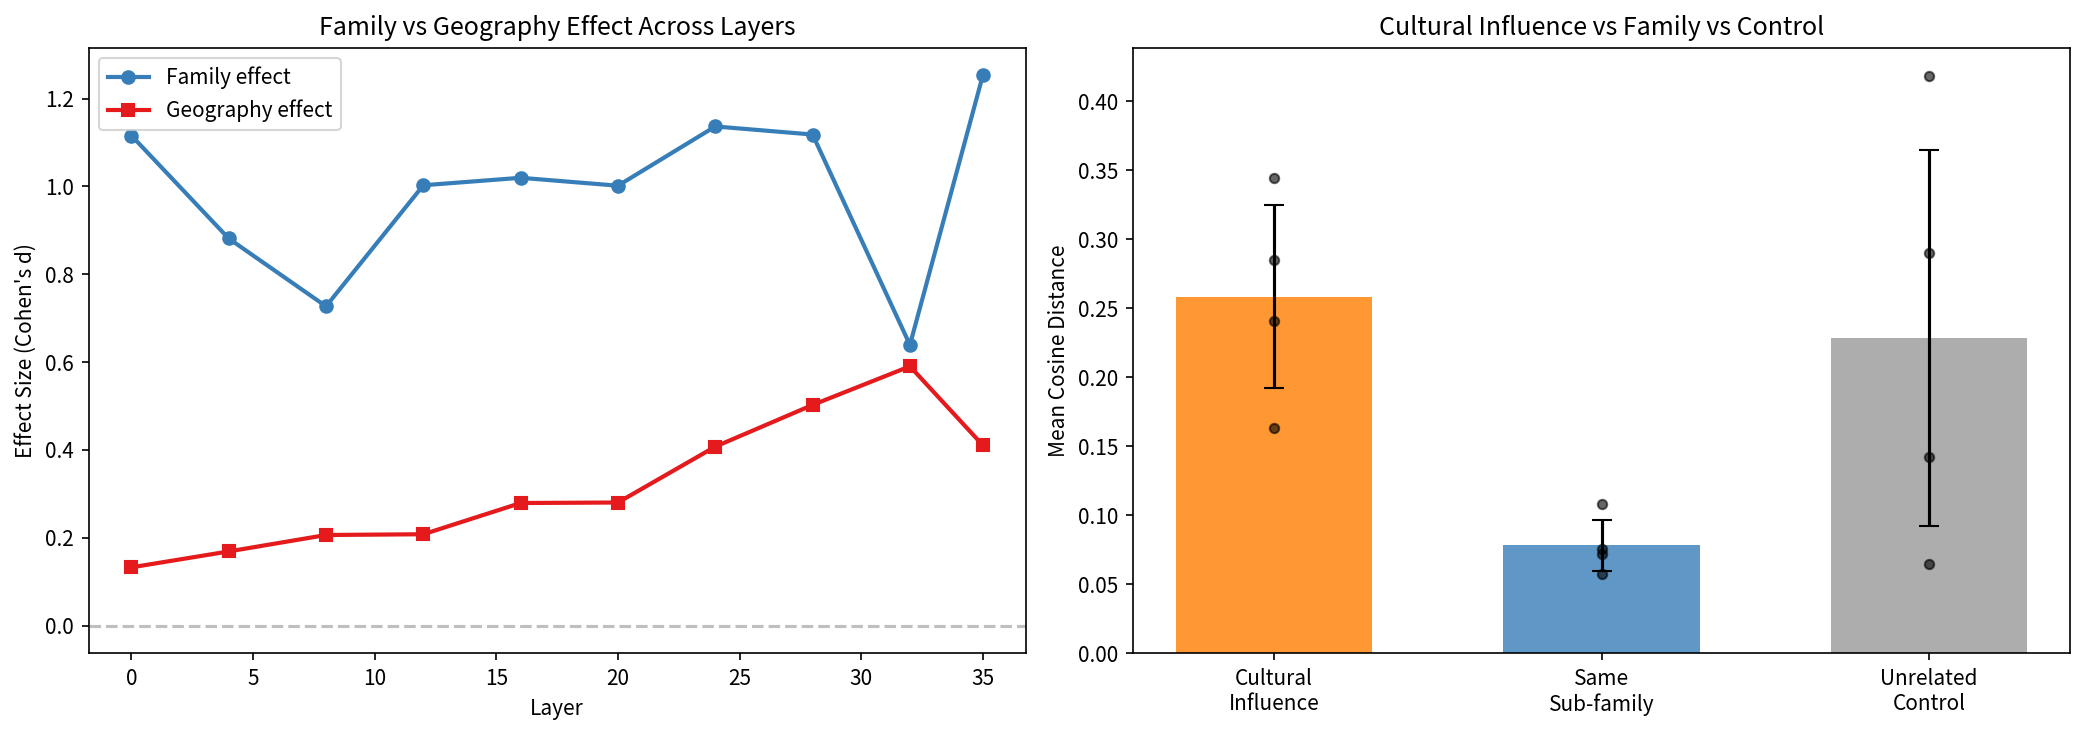

Saved multilayer_cultural.png


In [8]:
# ===== MULTI-LAYER ANALYSIS =====
# For each target layer, compute family effect and geography effect

family_effects = []
geo_effects = []
layer_labels = []

for L in TARGET_LAYERS:
    # Compute centroid distances at this layer
    centroids_L = {lc: multi_acts[lc][L].mean(axis=0) for lc in lang_list}
    dm = np.zeros((n_langs, n_langs))
    for i, l1 in enumerate(lang_list):
        for j, l2 in enumerate(lang_list):
            if i != j:
                dm[i, j] = cosine(centroids_L[l1], centroids_L[l2])

    d_vec = dm[upper]
    within_fam = d_vec[fam_mask].mean()
    between_fam = d_vec[~fam_mask].mean()
    within_geo = d_vec[geo_mask].mean()
    between_geo = d_vec[~geo_mask].mean()

    fam_eff = (between_fam - within_fam) / d_vec.std() if d_vec.std() > 0 else 0
    geo_eff = (between_geo - within_geo) / d_vec.std() if d_vec.std() > 0 else 0

    family_effects.append(fam_eff)
    geo_effects.append(geo_eff)
    layer_labels.append(f'L{L}')
    print(f'L{L:2d}: family_d={fam_eff:.3f}  geo_d={geo_eff:.3f}  ratio={fam_eff/geo_eff:.2f}' if geo_eff != 0 else f'L{L:2d}: family_d={fam_eff:.3f}  geo_d={geo_eff:.3f}')

# ===== CULTURAL INFLUENCE ANALYSIS =====
# Are culturally linked languages closer than their family would predict?
print('\n=== Cultural Influence Distances (L16, cosine) ===')
L = 16
c = {lc: multi_acts[lc][L].mean(axis=0) for lc in lang_list}

cultural_pairs = [
    ('ZHO', 'JPN', 'Chinese → Japanese (cultural)'),
    ('ZHO', 'KOR', 'Chinese → Korean (cultural)'),
    ('JPN', 'KOR', 'Japanese ↔ Korean (geographic)'),
    ('ARA', 'FAS', 'Arabic → Persian (cultural)'),
    ('ARA', 'TUR', 'Arabic → Turkish (cultural)'),
    ('FAS', 'TUR', 'Persian ↔ Turkish (geographic)'),
    ('ENG', 'DEU', 'English ↔ German (family: Germanic)'),
    ('FRA', 'SPA', 'French ↔ Spanish (family: Romance)'),
    ('FRA', 'ITA', 'French ↔ Italian (family: Romance)'),
    ('SPA', 'POR', 'Spanish ↔ Portuguese (family: Romance)'),
    ('ENG', 'FRA', 'English ↔ French (geography, diff family)'),
    ('RUS', 'DEU', 'Russian ↔ German (diff family, diff geo)'),
    ('ZHO', 'ARA', 'Chinese ↔ Arabic (control: unrelated)'),
    ('JPN', 'SPA', 'Japanese ↔ Spanish (control: unrelated)'),
    ('HIN', 'FRA', 'Hindi ↔ French (same family IE, diff geo)'),
    ('HIN', 'FAS', 'Hindi ↔ Persian (same family IE, close geo)'),
]

for l1, l2, desc in cultural_pairs:
    d = cosine(c[l1], c[l2])
    print(f'  {l1}-{l2}: {d:.4f}  ({desc})')

# ===== EAST ASIA FOCUS =====
print('\n=== East Asian Focus (ZHO, JPN, KOR) ===')
ea_langs = ['ZHO', 'JPN', 'KOR']
ea_dists = {f'{l1}-{l2}': cosine(c[l1], c[l2]) for l1 in ea_langs for l2 in ea_langs if l1 < l2}
# Compare to mean distance of non-EA IE languages to each other
ie_langs = [lc for lc in lang_list if LANG_META[lc]['family'] == 'Indo-European']
ie_dists = [cosine(c[l1], c[l2]) for l1 in ie_langs for l2 in ie_langs if l1 < l2]
print(f'  East Asian pairwise (ZHO-JPN, ZHO-KOR, JPN-KOR): {list(ea_dists.values())}')
print(f'  Mean East Asian distance: {np.mean(list(ea_dists.values())):.4f}')
print(f'  Mean Indo-European distance: {np.mean(ie_dists):.4f}')
print(f'  → EA/IE ratio: {np.mean(list(ea_dists.values()))/np.mean(ie_dists):.3f}')

# === PLOT ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Layer-by-layer family vs geography effect
ax = axes[0]
ax.plot(TARGET_LAYERS, family_effects, 'o-', color='#377eb8', label='Family effect', linewidth=2, markersize=6)
ax.plot(TARGET_LAYERS, geo_effects, 's-', color='#e41a1c', label='Geography effect', linewidth=2, markersize=6)
ax.set_xlabel('Layer')
ax.set_ylabel("Effect Size (Cohen's d)")
ax.set_title('Family vs Geography Effect Across Layers')
ax.legend(fontsize=10)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# 2. Cultural influence pairs vs controls
ax = axes[1]
cultural_d = [cosine(c['ZHO'], c['JPN']), cosine(c['ARA'], c['FAS']),
              cosine(c['ARA'], c['TUR']), cosine(c['ZHO'], c['KOR'])]
family_d = [cosine(c['ENG'], c['DEU']), cosine(c['FRA'], c['SPA']),
            cosine(c['FRA'], c['ITA']), cosine(c['SPA'], c['POR'])]
control_d = [cosine(c['ZHO'], c['ARA']), cosine(c['JPN'], c['SPA']),
             cosine(c['HIN'], c['DEU']), cosine(c['RUS'], c['TUR'])]

categories = ['Cultural\nInfluence', 'Same\nSub-family', 'Unrelated\nControl']
means = [np.mean(cultural_d), np.mean(family_d), np.mean(control_d)]
stds = [np.std(cultural_d), np.std(family_d), np.std(control_d)]
colors = ['#ff7f00', '#377eb8', '#999999']
bars = ax.bar(categories, means, yerr=stds, color=colors, alpha=0.8, capsize=5, width=0.6)
ax.set_ylabel('Mean Cosine Distance')
ax.set_title('Cultural Influence vs Family vs Control')
# Add individual points
for i, (pts, cat_x) in enumerate(zip([cultural_d, family_d, control_d], range(3))):
    ax.scatter([cat_x]*len(pts), pts, color='black', s=20, zorder=5, alpha=0.6)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'multilayer_cultural.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved multilayer_cultural.png')

In [9]:
# ===== SUMMARY =====
print('=' * 60)
print('EXPERIMENT 12 SUMMARY')
print('=' * 60)

print('\n--- Part A: Dynasty Trajectory ---')
print(f'Dynasties: {" → ".join(dynasty_labels)}')
for d_label in dynasty_labels:
    m, s = aes_proj[d_label]
    print(f'  {d_label}: aesthetic_proj = {m:.2f} ± {s:.2f}')

# Dynasty chronological distance vs activation distance
chrono = {d: i for i, d in enumerate(dynasty_labels)}
d_chrono_pairs = []
d_act_pairs = []
for i, d1 in enumerate(dynasty_labels):
    c1 = dynasty_acts[d1][16].mean(axis=0)
    for j, d2 in enumerate(dynasty_labels):
        if j > i:
            c2 = dynasty_acts[d2][16].mean(axis=0)
            d_chrono_pairs.append(abs(chrono[d1] - chrono[d2]))
            d_act_pairs.append(cosine(c1, c2))
r_chrono, p_chrono = stats.spearmanr(d_chrono_pairs, d_act_pairs)
print(f'\nChronological distance vs activation distance: r={r_chrono:.3f}, p={p_chrono:.4f}')

print('\n--- Part B: Multilingual Map ---')
print(f'Languages: {n_langs}')
best_layer_fam = TARGET_LAYERS[np.argmax(family_effects)]
best_layer_geo = TARGET_LAYERS[np.argmax(geo_effects)]
print(f'Peak family effect: L{best_layer_fam} (d={max(family_effects):.3f})')
print(f'Peak geography effect: L{best_layer_geo} (d={max(geo_effects):.3f})')
print(f'Family Mantel r={obs_r_fam:.4f}, p={p_mantel_fam:.4f}')
print(f'Geography Mantel r={obs_r_geo:.4f}, p={p_mantel_geo:.4f}')

print('\n--- Part C: Cultural Influence ---')
print(f'Cultural influence pairs mean: {np.mean(cultural_d):.4f}')
print(f'Same sub-family pairs mean:    {np.mean(family_d):.4f}')
print(f'Unrelated control pairs mean:  {np.mean(control_d):.4f}')

winner = 'Family' if obs_r_fam > obs_r_geo else 'Geography'
print(f'\n→ VERDICT: {winner} is a stronger predictor of poetic distance')

# ===== SAVE =====
# Prepare centroid distance matrix at L16
np.savez(OUTPUT_DIR / 'exp12_results.npz',
    lang_list=np.array(lang_list),
    dist_matrix=dist_matrix,
    family_effects=np.array(family_effects),
    geo_effects=np.array(geo_effects),
    target_layers=np.array(TARGET_LAYERS),
    dynasty_labels=np.array(dynasty_labels),
    dynasty_aes_proj=np.array([(aes_proj[d][0], aes_proj[d][1]) for d in dynasty_labels]),
    mantel_r_fam=obs_r_fam, mantel_p_fam=p_mantel_fam,
    mantel_r_geo=obs_r_geo, mantel_p_geo=p_mantel_geo,
    chrono_corr_r=r_chrono, chrono_corr_p=p_chrono,
)
print(f'\nResults saved to {OUTPUT_DIR / "exp12_results.npz"}')
print(f'Plots saved to {OUTPUT_DIR}')

EXPERIMENT 12 SUMMARY

--- Part A: Dynasty Trajectory ---
Dynasties: Tang → Song → Yuan → Ming → Qing
  Tang: aesthetic_proj = 5.47 ± 0.95
  Song: aesthetic_proj = 5.66 ± 1.09
  Yuan: aesthetic_proj = 4.74 ± 1.62
  Ming: aesthetic_proj = 5.66 ± 1.15
  Qing: aesthetic_proj = 4.77 ± 1.26

Chronological distance vs activation distance: r=0.197, p=0.5853

--- Part B: Multilingual Map ---
Languages: 14
Peak family effect: L35 (d=1.254)
Peak geography effect: L32 (d=0.590)
Family Mantel r=0.4986, p=0.0158
Geography Mantel r=0.0977, p=0.1494

--- Part C: Cultural Influence ---
Cultural influence pairs mean: 0.2583
Same sub-family pairs mean:    0.0782
Unrelated control pairs mean:  0.2286

→ VERDICT: Family is a stronger predictor of poetic distance

Results saved to /workspace/Data/direction_E/exp12_results.npz
Plots saved to /workspace/Data/direction_E
